# Polished Visualizations (Keystone Project)
 
Goal: Use CDC BRFSS 2023 survey data to identify lifestyle behaviors most associated with poor health outcomes, and communicate findings using ethical, accessible visualizations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
BRFSS2023_df = pd.read_csv(r"C:\Users\alin2\Downloads\BRFSS2023.csv")
BRFSS2023_df.shape


(433323, 350)

In [3]:
BRFSS2023_df.head()


,_state,fmonth,idate,imonth,iday,iyear,dispcode,seqno,_psu,ctelenm1,...,drocdy4_,_rfbing6,_drnkwk2,_rfdrhv8,_flshot7,_pneumo3,_aidtst4,_rfseat2,_rfseat3,_drnkdrv
0,1,1,3012023,3,1,2023,1100,2023000001,2023000001,1.0,...,0,1,0,1,2.0,2.0,2.0,1,1,9
1,1,1,1062023,1,6,2023,1100,2023000002,2023000002,1.0,...,0,1,0,1,1.0,1.0,2.0,1,1,9
2,1,1,3082023,3,8,2023,1100,2023000003,2023000003,1.0,...,0,1,0,1,1.0,1.0,2.0,1,1,9
3,1,1,3062023,3,6,2023,1100,2023000004,2023000004,1.0,...,0,1,0,1,1.0,1.0,1.0,1,1,9
4,1,1,1062023,1,6,2023,1100,2023000005,2023000005,1.0,...,7,1,47,1,2.0,1.0,2.0,1,1,2


In [4]:
BRFSS2023_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433323 entries, 0 to 433322
Columns: 350 entries, _state to _drnkdrv
dtypes: float64(294), int64(56)
memory usage: 1.1 GB



## Selecting Focus Variables

The BRFSS dataset contains many coded variables, so I selected a small set that clearly represents
lifestyle behaviors and health context.

**Lifestyle behaviors:**
- `_drnkwk2`: Drinks per week  
- `_rfbing6`: Binge drinking risk  
- `_drnkdrv`: Drinking and driving risk  

**Health context:**
- `_pneumo3`: Pneumococcal vaccination status  

These variables are commonly used BRFSS recoded measures and require careful handling of
special codes and missing values, allowing me to demonstrate ethical data cleaning and
clear, honest visualization.


In [5]:
focus_cols = [
    "_drnkwk2",
    "_rfbing6",
    "_drnkdrv",
    "_pneumo3"
]

df_focus = BRFSS2023_df[focus_cols].copy()
df_focus.head()


,_drnkwk2,_rfbing6,_drnkdrv,_pneumo3
0,0,1,9,2.0
1,0,1,9,1.0
2,0,1,9,1.0
3,0,1,9,1.0
4,47,1,2,1.0


## Ethical Data Cleaning Decisions

For the selected variables (`_drnkwk2`, `_rfbing6`, `_drnkdrv`, `_pneumo3`):
- All special BRFSS codes are converted to missing values
- No values are imputed or altered
- Missingness is preserved and acknowledged in the analysis

These steps ensure the visualizations reflect the data honestly and avoid misleading
interpretations.

In [6]:

import numpy as np

for col in df_focus.columns:
    df_focus[col] = pd.to_numeric(df_focus[col], errors="coerce")

special_codes = [7, 9, 77, 99, 777, 999, 7777, 9999, 99900]

df_focus = df_focus.replace(special_codes, np.nan)

df_focus.isna().sum()


_drnkwk2     32825
_rfbing6     33409
_drnkdrv    221590
_pneumo3    284457
dtype: int64

# Data Availability and Missingness

After cleaning special BRFSS codes, a substantial amount of missing data remains in several
variables:

- `_drnkwk2` (drinks per week): ~32,800 missing values  
- `_rfbing6` (binge drinking risk): ~33,400 missing values  
- `_drnkdrv` (drinking and driving risk): ~221,600 missing values  
- `_pneumo3` (pneumococcal vaccination): ~284,400 missing values  

This missingness reflects how BRFSS collects sensitive health and behavior data and varies
by question type.

Rather than removing large portions of the dataset, missing values are preserved and
acknowledged in each visualization. Charts are designed to clearly communicate what the
data shows while avoiding overinterpretation where responses are limited.

This approach prioritizes transparency and ethical communication over forcing complete data.


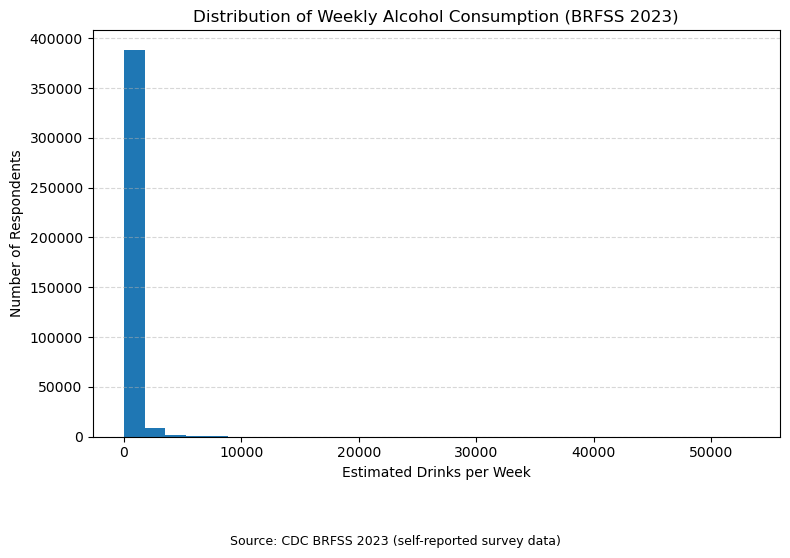

In [7]:
drinks = df_focus["_drnkwk2"].dropna()

plt.figure(figsize=(8,5))
plt.hist(drinks, bins=30)

plt.title("Distribution of Weekly Alcohol Consumption (BRFSS 2023)")
plt.xlabel("Estimated Drinks per Week")
plt.ylabel("Number of Respondents")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.figtext(
    0.5, -0.1,
    "Source: CDC BRFSS 2023 (self-reported survey data)",
    ha="center", fontsize=9
)

plt.tight_layout()
plt.show()


# Interpretation of Weekly Alcohol Consumption Distribution

The histogram shows a highly right-skewed distribution of estimated weekly alcohol consumption.
Most respondents report low or zero drinks per week, while a small number report extremely high
values.

This pattern is expected in self-reported public health data and highlights two important points:

- Alcohol consumption is concentrated at lower levels for most respondents
- A small number of extreme values significantly affect the scale and visual appearance

To avoid misleading interpretation, the visualization is presented without truncating the x-axis.
Rather than emphasizing extremes, this chart is used to understand overall distribution shape
and data quality, not to draw conclusions about average behavior.

This reinforces the importance of cautious interpretation when working with skewed survey data.


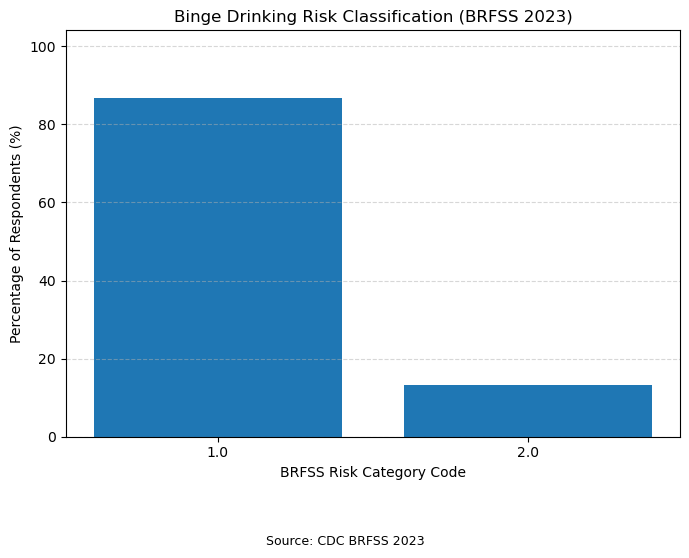

In [8]:
binge_counts = df_focus["_rfbing6"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(7,5))
plt.bar(binge_counts.index.astype(str), binge_counts.values)

plt.title("Binge Drinking Risk Classification (BRFSS 2023)")
plt.xlabel("BRFSS Risk Category Code")
plt.ylabel("Percentage of Respondents (%)")
plt.ylim(0, binge_counts.max() * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.figtext(
    0.5, -0.1,
    "Source: CDC BRFSS 2023",
    ha="center", fontsize=9
)

plt.tight_layout()
plt.show()


# Interpretation of Binge Drinking Risk Classification

This chart compares the percentage of respondents classified under the BRFSS binge drinking
risk indicator.

Most respondents fall into category `1`, while a smaller proportion fall into category `2`.
This suggests that binge drinking risk is not evenly distributed across the population and
is concentrated within a minority of respondents.

It is important to note that these categories are based on BRFSS-defined thresholds and
represent risk classification rather than direct measurement of alcohol intake.

To avoid misleading interpretation:
- The y-axis begins at zero
- Neutral colors are used
- Category codes are shown without emotional framing

This visualization is intended to describe population-level patterns, not to assess
individual behavior or causality.


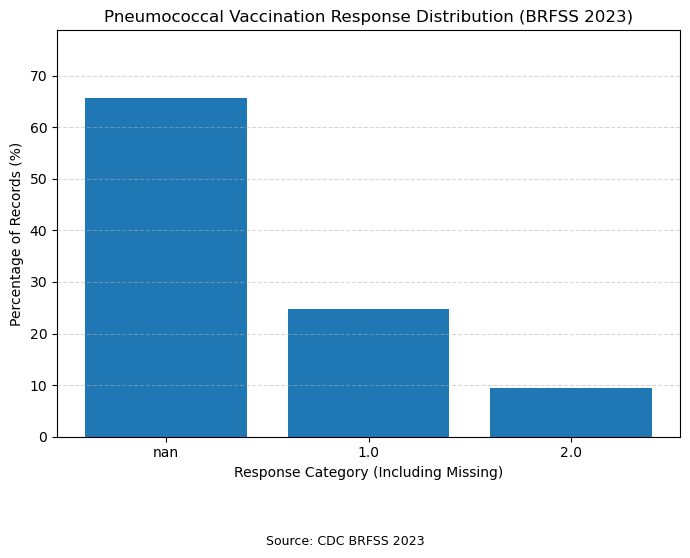

In [9]:
pneumo_counts = df_focus["_pneumo3"].value_counts(dropna=False, normalize=True) * 100

plt.figure(figsize=(7,5))
plt.bar(pneumo_counts.index.astype(str), pneumo_counts.values)

plt.title("Pneumococcal Vaccination Response Distribution (BRFSS 2023)")
plt.xlabel("Response Category (Including Missing)")
plt.ylabel("Percentage of Records (%)")
plt.ylim(0, pneumo_counts.max() * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.figtext(
    0.5, -0.1,
    "Source: CDC BRFSS 2023",
    ha="center", fontsize=9
)

plt.tight_layout()
plt.show()


# Interpretation of Pneumococcal Vaccination Response Distribution

This chart shows the distribution of responses for the pneumococcal vaccination variable,
including missing values.

A large proportion of records fall into the missing category, indicating that this question
was either not applicable to many respondents or not answered. This is expected, as
pneumococcal vaccination questions are often age- or risk-specific within BRFSS.

Rather than excluding missing values, they are displayed explicitly to provide transparency
about data availability and limitations.

This visualization emphasizes that absence of data does not imply absence of vaccination
and highlights the importance of contextual awareness when interpreting public health
survey results.
